<a href="https://colab.research.google.com/github/jhj5445/portfolio/blob/main/hmmtest%EC%88%98%EC%A0%95%EC%A4%91%EB%B2%84%EC%A0%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install hmmlearn
! pip install fredapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: GMM(현재 진단) vs HMM(미래 예측) A/B 테스트 포트폴리오 생성 ===
=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료/비상브레이크 적용 ===
=== 📊 4단계: GMM(현재) vs HMM(미래예측) 성과 정면 승부 ===

🏆 GMM (현재 대응) vs HMM (미래 예측) 최종 백테스트 🏆
전략 이름                  | CAGR (%)     | MDD (%)     
-----------------------------------------------------------------
🤖 1. GMM (현재 국면)     |     7.57 % |   -49.26 %
🔮 2. HMM (미래 예측)     |     9.12 % |   -39.72 %
📈 3. SPY (벤치마크)      |     7.74 % |   -55.19 %



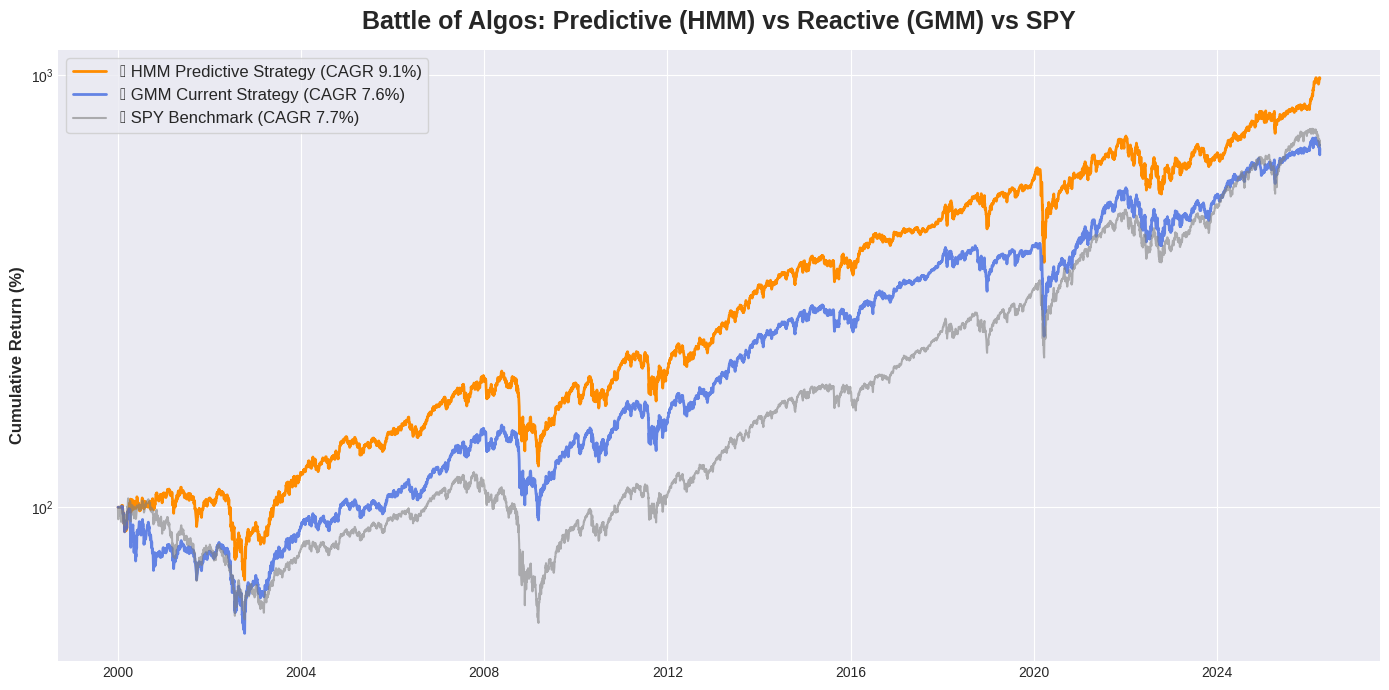

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_baa_yield = fred.get_series('BAA')   # Baa 회사채 (1919년~)
    s_10y_yield = fred.get_series('GS10')  # 10년물 국채 (1953년~)
    s_baa = s_baa_yield - s_10y_yield      # 우리가 직접 만든 신용 스프레드

    s_indpro = fred.get_series('INDPRO')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    # 1. 일단 다 합치고 월말 기준으로 ffill만 맞춥니다. (dropna 절대 금지!)
    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill()

    # 2. 데이터가 꽉 차 있는(과거부터 있는) 상태에서 모멘텀을 계산합니다.
    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(12)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(12)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # 3. Z-스코어 계산도 미리 해버립니다. (각 지표별로 과거 데이터가 살아있으므로 워밍업이 빠름)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(120).std()

    # 4. 모든 계산이 끝난 후, 모델에 넣기 직전에 깔끔하게 자릅니다.
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 피델리티 오리지널 로직
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ GMM(현재 대응) vs HMM(미래 예측) 타겟 비중 동시 산출
# ==============================================================================
print("=== ⚙️ 3단계: GMM(현재 진단) vs HMM(미래 예측) A/B 테스트 포트폴리오 생성 ===")

from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM

eom_dates = etf_px.resample('ME').last().index

# 💡 두 전략의 비중을 따로 담을 데이터프레임 생성
target_weights_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
target_weights_hmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

# 피델리티 국면 라벨링 함수
def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]

    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

# 확률 기반 섹터 비중 배분 함수 (중복 코드 제거)
def allocate_weights(probs_dict, date, target_df):
    threshold = 0.10
    filtered_probs = {regime: prob for regime, prob in probs_dict.items() if prob >= threshold}
    if not filtered_probs:
        dominant_regime = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant_regime: 1.0}
    total_prob = sum(filtered_probs.values())
    normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}
    for regime, prob in normalized_probs.items():
        sectors = cycle_playbook[regime]
        weight_per_sector = prob / len(sectors)
        for s in sectors:
            target_df.loc[date, s] += weight_per_sector

# 학습 루프 시작
for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # 🤖 [전략 A] GMM: "현재 확인된 국면에 투자"
        gmm = GaussianMixture(n_components=4, covariance_type='diag', random_state=42)
        gmm.fit(df_train_current)
        regime_map_gmm = get_regime_mapping(gmm.means_)
        raw_probs_gmm = gmm.predict_proba(current_data)[0]
        current_probs_gmm = {regime_map_gmm[j]: raw_probs_gmm[j] for j in range(4)}

        allocate_weights(current_probs_gmm, date, target_weights_gmm)

        # 🔮 [전략 B] HMM: "예측된 '다음 달' 국면에 투자"
        # Warning 해결을 위해 covariance_type='diag', n_iter=500 적용
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            regime_map_hmm = get_regime_mapping(hmm.means_)
            hidden_states_proba = hmm.predict_proba(df_train_current)
            current_proba_hmm_raw = hidden_states_proba[-1]

            # 💡 핵심: 전이 행렬을 곱해서 '미래(다음 달)' 확률 산출!
            next_proba_hmm_raw = np.dot(current_proba_hmm_raw, hmm.transmat_)
            next_probs_hmm = {regime_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}

            allocate_weights(next_probs_hmm, date, target_weights_hmm)
        except:
            # 학습 실패 시 GMM 결과로 대체 (안전장치)
            allocate_weights(current_probs_gmm, date, target_weights_hmm)

    else:
        target_weights_gmm.loc[date, 'SPY'] = 1.0
        target_weights_hmm.loc[date, 'SPY'] = 1.0

# ==============================================================================
# 3-2. ⚙️ 공정한 백테스트 시뮬레이터 함수 (200일선 비상브레이크 포함)
# ==============================================================================
print("=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료/비상브레이크 적용 ===")

# 달력 월말을 실제 마지막 거래일로 변환
target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

# 200일선 비상 브레이크 (SPY 기준)
spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma

# 백테스트 함수 정의
def run_simulation(target_weights_df, name=""):
    tw = target_weights_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]



    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    costs = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            costs[i] = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - costs[i]

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

# 두 전략 시뮬레이션 실행
ret_gmm = run_simulation(target_weights_gmm, "GMM")
ret_hmm = run_simulation(target_weights_hmm, "HMM")

# ==============================================================================
# 4. 🚀 최종 성과 비교 및 시각화 (GMM vs HMM 예측 vs SPY)
# ==============================================================================
print("=== 📊 4단계: GMM(현재) vs HMM(미래예측) 성과 정면 승부 ===")

valid_start = '2000-01-01'
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
ret_gmm_valid = ret_gmm.loc[valid_start:]
ret_hmm_valid = ret_hmm.loc[valid_start:]

cum_spy = (1 + spy_ret_valid).cumprod()
cum_gmm = (1 + ret_gmm_valid).cumprod()
cum_hmm = (1 + ret_hmm_valid).cumprod()

def get_metrics(cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    return cagr, mdd

spy_c, spy_m = get_metrics(cum_spy)
gmm_c, gmm_m = get_metrics(cum_gmm)
hmm_c, hmm_m = get_metrics(cum_hmm)

print("\n" + "="*65)
print(f"🏆 GMM (현재 대응) vs HMM (미래 예측) 최종 백테스트 🏆")
print("="*65)
print(f"{'전략 이름':<22} | {'CAGR (%)':<12} | {'MDD (%)':<12}")
print("-" * 65)
print(f"{'🤖 1. GMM (현재 국면)':<20} | {gmm_c*100:>8.2f} % | {gmm_m*100:>8.2f} %")
print(f"{'🔮 2. HMM (미래 예측)':<20} | {hmm_c*100:>8.2f} % | {hmm_m*100:>8.2f} %")
print(f"{'📈 3. SPY (벤치마크)':<20} | {spy_c*100:>8.2f} % | {spy_m*100:>8.2f} %")
print("="*65 + "\n")

# 시각화
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(cum_hmm.index, cum_hmm * 100, label=f'🔮 HMM Predictive Strategy (CAGR {hmm_c*100:.1f}%)', color='darkorange', linewidth=2)
plt.plot(cum_gmm.index, cum_gmm * 100, label=f'🤖 GMM Current Strategy (CAGR {gmm_c*100:.1f}%)', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(cum_spy.index, cum_spy * 100, label=f'📈 SPY Benchmark (CAGR {spy_c*100:.1f}%)', color='gray', alpha=0.6)

plt.title('Battle of Algos: Predictive (HMM) vs Reactive (GMM) vs SPY', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
plt.yscale('log') # 장기 복리 효과를 명확히 보기 위해 Y축 로그 스케일 적용
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

In [3]:
print(np.round(hmm.transmat_, 3))

[[0.932 0.    0.05  0.017]
 [0.085 0.915 0.    0.   ]
 [0.    0.    0.966 0.034]
 [0.    0.021 0.016 0.963]]


=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: 4가지 전략 비중 산출 및 국면 확률 추적 중... ===
👀 [변화 조짐] 2004-06-30 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 26.7%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2004-07-31 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 23.3%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2004-12-31 | 대세(Early) 유지되나, ➡️ 'Late' 갈 확률이 20.7%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2006-02-28 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 23.3%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2006-03-31 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 36.5%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2006-07-31 | 대세(Early) 유지되나, ➡️ 'Late' 갈 확률이 26.2%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2007-07-31 | 대세(Early) 유지되나, ➡️ 'Late' 갈 확률이 27.5%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2008-09-30 | 대세(Recession) 유지되나, ➡️ 'Mid' 갈 확률이 31.9%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2012-10-31 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 29.0%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2012-11-30 | 대세(Early) 유지되나, ➡️ 'Late' 갈 확률이 20.8%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2016-10-31 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 32.6%로 상승 (블렌딩 작동!)
👀 [변화 조짐] 2016-12-31 | 대세(Late) 유지되나, ➡️ 'Early' 갈 확률이 26.0%

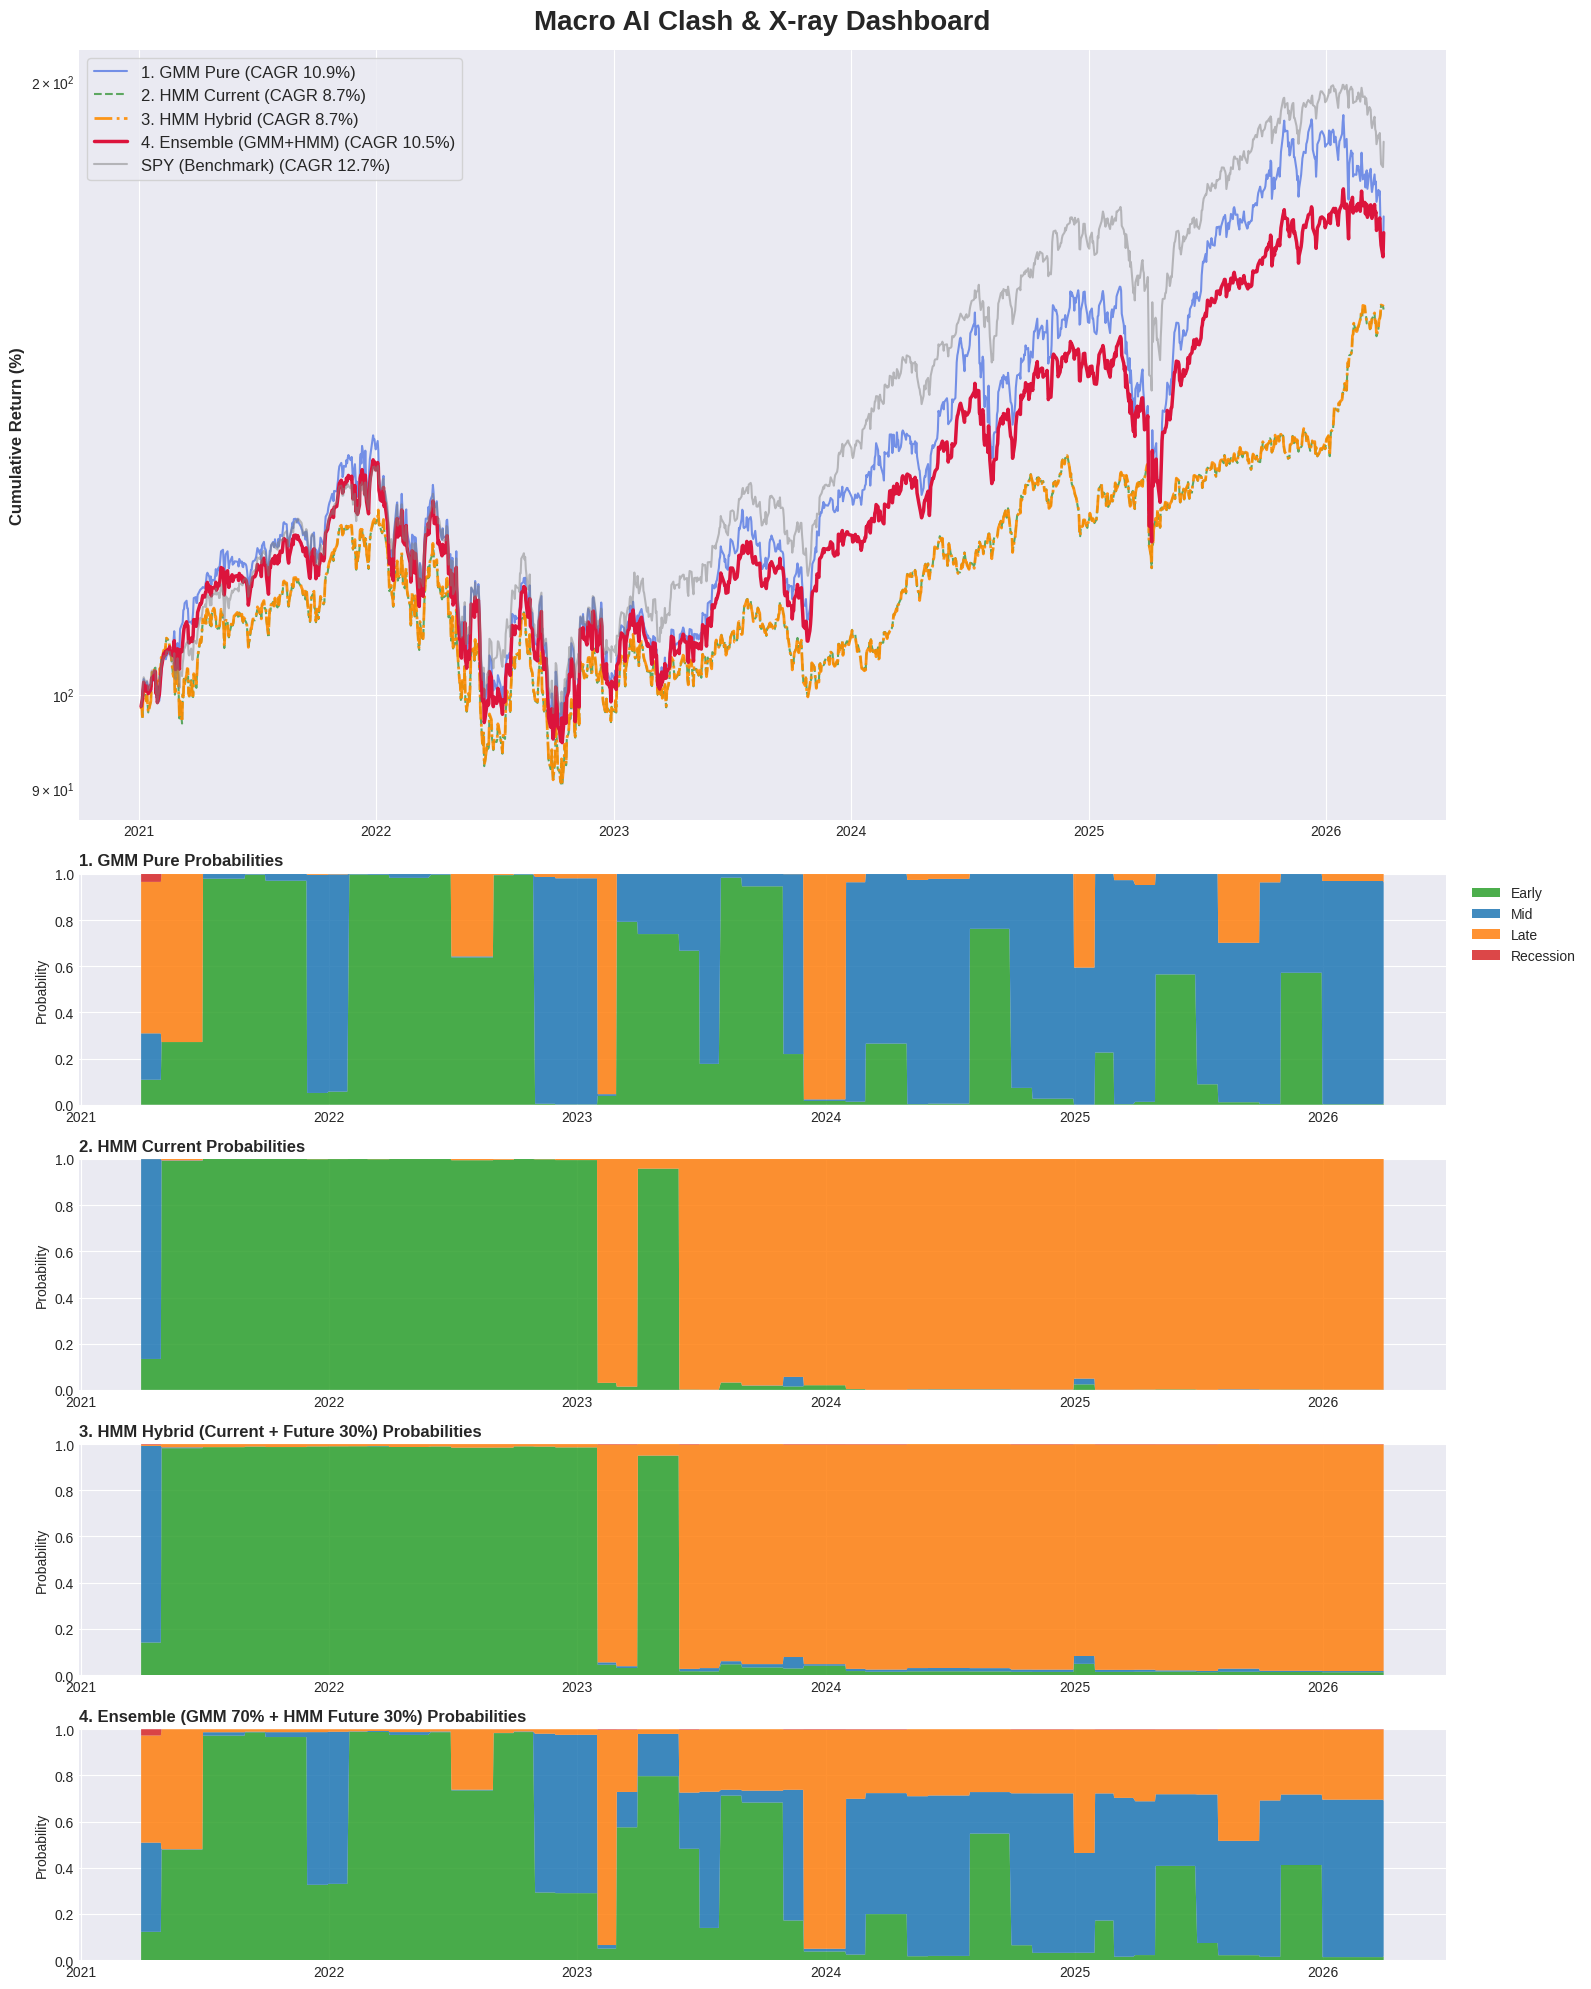

In [39]:
# 현재 이코드 중심으로 보고 있음

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (120개월 롤링 Z-스코어)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_baa_yield = fred.get_series('BAA')
    s_10y_yield = fred.get_series('GS10')
    s_baa = s_baa_yield - s_10y_yield

    s_indpro = fred.get_series('INDPRO')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')
    #s_cpi = fred.get_series('CPIAUCSL')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    #df_macro = pd.concat([s_indpro, s_baa, s_cpi, s_payems, s_t10y2y], axis=1)

    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill()

    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(6)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].pct_change(6)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(6)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(120).mean()) / df_macro[features].rolling(120).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정.")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY', 'QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 4가지 전략 동시 타겟 비중 산출 및 💡국면 확률 추적!
# ==============================================================================
print("=== ⚙️ 3단계: 4가지 전략 비중 산출 및 국면 확률 추적 중... ===")

eom_dates = etf_px.resample('ME').last().index

tw_m1_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_m2_hmm_curr = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_m3_hmm_hyb = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
tw_m4_ens = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

# 💡 국면 확률 기록용 리스트
hist_m1, hist_m2, hist_m3, hist_m4 = [], [], [], []

HMM_THRESHOLD = 0.60
FUT_WEIGHT = 0.30
CURR_WEIGHT = 1.0 - FUT_WEIGHT

def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]
    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

def probs_to_weights(probs_dict):
    filtered_probs = {k: v for k, v in probs_dict.items() if v >= 0.10}
    if not filtered_probs:
        dominant = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant: 1.0}
    total = sum(filtered_probs.values())
    norm_probs = {k: v / total for k, v in filtered_probs.items()}

    w_series = pd.Series(0.0, index=etf_px.columns)
    for regime, prob in norm_probs.items():
        sectors = cycle_playbook[regime]
        for s in sectors:
            w_series[s] += prob / len(sectors)
    return w_series

for date in eom_dates:
    #prob_date = date - pd.DateOffset(months=1)
    #df_train_current = df_z.loc[:prob_date]
    #print(prob_date)
    df_train_current = df_z[df_z.index < date]
    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # 🤖 GMM (현재)
        gmm = GaussianMixture(n_components=4, covariance_type='diag', random_state=42)
        gmm.fit(df_train_current)
        reg_map_gmm = get_regime_mapping(gmm.means_)
        probs_gmm_raw = gmm.predict_proba(current_data)[0]
        probs_gmm = {reg_map_gmm[j]: probs_gmm_raw[j] for j in range(4)}
        w_gmm = probs_to_weights(probs_gmm)

        # 🔮 HMM (현재 & 미래)
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            reg_map_hmm = get_regime_mapping(hmm.means_)

            curr_proba_hmm_raw = hmm.predict_proba(df_train_current)[-1]
            probs_hmm_curr = {reg_map_hmm[j]: curr_proba_hmm_raw[j] for j in range(4)}
            w_hmm_curr = probs_to_weights(probs_hmm_curr)

            next_proba_hmm_raw = np.dot(curr_proba_hmm_raw, hmm.transmat_)
            probs_hmm_fut = {reg_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}
            w_hmm_fut = probs_to_weights(probs_hmm_fut)

            max_fut_prob = max(probs_hmm_fut.values())
            is_confident = max_fut_prob >= HMM_THRESHOLD
            curr_dominant = max(probs_hmm_curr, key=probs_hmm_curr.get) # 현재 가장 확률 높은 국면
            fut_dominant = max(probs_hmm_fut, key=probs_hmm_fut.get)   # 미래 가장 확률 높은 국면

# ==========================================
            # 💡 [수정된 부분] 1등이 바뀌지 않더라도, 2등 국면이 '20%' 이상 치고 올라오는 조짐 포착!
            # ==========================================
            if is_confident:
                curr_dominant = max(probs_hmm_curr, key=probs_hmm_curr.get)

                # 미래 확률 중 '현재 1등'을 제외한 나머지 국면들 중에서 가장 높은 확률(추격자) 찾기
                challenger_state = None
                challenger_prob = 0.0
                for state, prob in probs_hmm_fut.items():
                    if state != curr_dominant and prob > challenger_prob:
                        challenger_state = state
                        challenger_prob = prob

                # 추격자 국면의 확률이 20% 이상으로 꿈틀대면 출력 (조짐 포착!)
                if challenger_prob >= 0.20:
                    print(f"👀 [변화 조짐] {date.strftime('%Y-%m-%d')} | 대세({curr_dominant}) 유지되나, ➡️ '{challenger_state}' 갈 확률이 {challenger_prob*100:.1f}%로 상승 (블렌딩 작동!)")
            # ==========================================

        except:
            w_hmm_curr, w_hmm_fut = w_gmm.copy(), w_gmm.copy()
            probs_hmm_curr, probs_hmm_fut = probs_gmm.copy(), probs_gmm.copy()
            is_confident = False

        # --- 🏆 비중 할당 및 확률 기록 ---
        # 1. GMM Pure
        tw_m1_gmm.loc[date] = w_gmm
        hist_m1.append({'Date': date, **probs_gmm})

        # 2. HMM Pure (Current)
        tw_m2_hmm_curr.loc[date] = w_hmm_curr
        hist_m2.append({'Date': date, **probs_hmm_curr})

        # 3. HMM Hybrid (Current + Future 30% Tilting)
        if is_confident:
            tw_m3_hmm_hyb.loc[date] = (w_hmm_curr * CURR_WEIGHT) + (w_hmm_fut * FUT_WEIGHT)
            hyb_probs = {k: (probs_hmm_curr[k] * CURR_WEIGHT) + (probs_hmm_fut[k] * FUT_WEIGHT) for k in cycle_playbook.keys()}
        else:
            tw_m3_hmm_hyb.loc[date] = w_hmm_curr
            hyb_probs = probs_hmm_curr.copy()
        hist_m3.append({'Date': date, **hyb_probs})

        # 4. GMM + HMM Ensemble
        if is_confident:
            tw_m4_ens.loc[date] = (w_gmm * CURR_WEIGHT) + (w_hmm_fut * FUT_WEIGHT)
            ens_probs = {k: (probs_gmm[k] * CURR_WEIGHT) + (probs_hmm_fut[k] * FUT_WEIGHT) for k in cycle_playbook.keys()}
        else:
            tw_m4_ens.loc[date] = w_gmm
            ens_probs = probs_gmm.copy()
        hist_m4.append({'Date': date, **ens_probs})

    else:
        for tw in [tw_m1_gmm, tw_m2_hmm_curr, tw_m3_hmm_hyb, tw_m4_ens]:
            tw.loc[date, 'SPY'] = 1.0

# DataFrame으로 변환
df_prob_m1 = pd.DataFrame(hist_m1).set_index('Date')
df_prob_m2 = pd.DataFrame(hist_m2).set_index('Date')
df_prob_m3 = pd.DataFrame(hist_m3).set_index('Date')
df_prob_m4 = pd.DataFrame(hist_m4).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 시뮬레이터 (수수료 적용)
# ==============================================================================
print("=== ⚙️ 3-2단계: 실전 매매 백테스트 및 수수료 차감 ===")
target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)
spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma


def run_simulation(tw_df):
    tw = tw_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    #bear_market_eom = is_bear_market.reindex(tw.index).fillna(False)
    #for d in tw.index:
    #    if bear_market_eom.loc[d]:
    #        tw.loc[d] = 0.0
    #       if 'VFISX' in tw.columns: tw.loc[d, 'VFISX'] = 1.0

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            cost = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()
        else:
            cost = 0.0

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - cost

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_m1 = run_simulation(tw_m1_gmm)
ret_m2 = run_simulation(tw_m2_hmm_curr)
ret_m3 = run_simulation(tw_m3_hmm_hyb)
ret_m4 = run_simulation(tw_m4_ens)

# ==============================================================================
# 4. 🚀 성과 비교 및 📊 뇌구조(Regime) 대시보드 시각화
# ==============================================================================
print("=== 📊 4단계: 최종 엑스레이(X-ray) 대시보드 출력 ===")

valid_start = '2021-01-01'
rets = {
    '1. GMM Pure': ret_m1.loc[valid_start:],
    '2. HMM Current': ret_m2.loc[valid_start:],
    '3. HMM Hybrid': ret_m3.loc[valid_start:],
    '4. Ensemble (GMM+HMM)': ret_m4.loc[valid_start:],
    'SPY (Benchmark)': daily_returns.loc[valid_start:, 'SPY']
}
cums = {name: (1 + ret).cumprod() for name, ret in rets.items()}

# --- 성과 텍스트 출력 ---
def get_metrics(ret, cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    sharpe = (ret.mean() / ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

print("\n" + "="*80)
print(f"{'Model Name':<28} | {'CAGR (%)':<10} | {'MDD (%)':<10} | {'Sharpe'}")
print("-" * 80)
for name in rets.keys():
    c, m, s = get_metrics(rets[name], cums[name])
    if 'SPY' in name: print("-" * 80)
    print(f"{name:<28} | {c*100:>7.2f} % | {m*100:>7.2f} % | {s:>6.2f}")
print("="*80 + "\n")

# --- 📊 5단 대시보드 그리기 ---
plt.style.use('seaborn-v0_8-darkgrid')
# 5개의 그래프 슬롯 생성 (수익률 창을 제일 크게)
fig, axes = plt.subplots(5, 1, figsize=(16, 20), gridspec_kw={'height_ratios': [4, 1.2, 1.2, 1.2, 1.2]})

# [1] 최상단: 누적 수익률 배틀
colors = ['royalblue', 'forestgreen', 'darkorange', 'crimson', 'gray']
styles = ['-', '--', '-.', '-', '-']
linewidths = [1.5, 1.5, 2, 2.5, 1.5]
alphas = [0.7, 0.7, 0.9, 1.0, 0.5]

for i, name in enumerate(cums.keys()):
    label_name = f"{name} (CAGR {get_metrics(rets[name], cums[name])[0]*100:.1f}%)"
    axes[0].plot(cums[name].index, cums[name] * 100, label=label_name,
                 color=colors[i], linestyle=styles[i], linewidth=linewidths[i], alpha=alphas[i])

axes[0].set_title('Macro AI Clash & X-ray Dashboard', fontsize=20, fontweight='bold', pad=15)
axes[0].set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].legend(loc='upper left', fontsize=12, frameon=True)

# [2~5] 하단: 각 모델의 뇌구조 (국면 확률)
regime_dfs = [
    (df_prob_m1, '1. GMM Pure Probabilities'),
    (df_prob_m2, '2. HMM Current Probabilities'),
    (df_prob_m3, '3. HMM Hybrid (Current + Future 30%) Probabilities'),
    (df_prob_m4, '4. Ensemble (GMM 70% + HMM Future 30%) Probabilities')
]

regime_colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Green(Early), Blue(Mid), Orange(Late), Red(Recession)
labels = ['Early', 'Mid', 'Late', 'Recession']

for i, (df_prob, title) in enumerate(regime_dfs):
    ax = axes[i+1]
    # 데이터를 수익률 차트의 X축(날짜)에 맞게 정렬 및 보간
    probs_aligned = df_prob.reindex(cums['1. GMM Pure'].index).ffill().dropna()

    # 0~1 사이로 확실히 맞추기 (안전장치)
    probs_aligned = probs_aligned[labels].div(probs_aligned[labels].sum(axis=1), axis=0)

    ax.stackplot(probs_aligned.index,
                 probs_aligned['Early'], probs_aligned['Mid'],
                 probs_aligned['Late'], probs_aligned['Recession'],
                 labels=labels, colors=regime_colors, alpha=0.85)

    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    if i == 0: # 첫 번째 스택플롯에만 범례 표시
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)

plt.tight_layout()
plt.show()

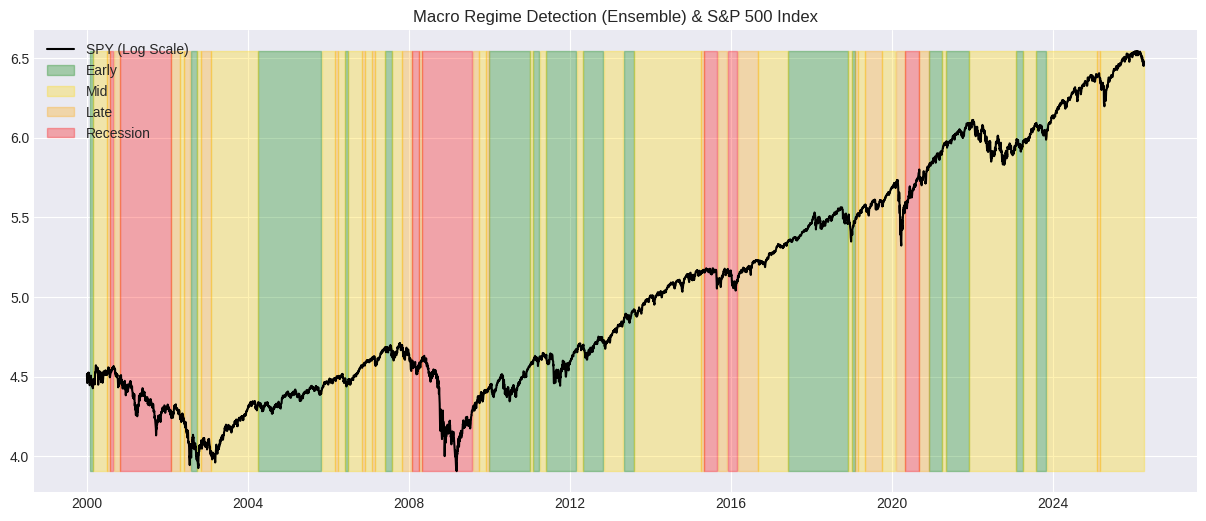

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
PRICE_DF = etf_px      # 일간 데이터 (Daily)
PROB_DF = df_prob_m4   # 월간 확률 데이터 (Monthly)
# ==========================================

# 색상 지정 (Early: 초록, Mid: 노랑, Late: 주황, Recession: 빨강)
color_map = {'Early': 'green', 'Mid': 'gold', 'Late': 'orange', 'Recession': 'red'}

plt.figure(figsize=(15, 6))

# SPY(S&P 500) 지수 라인 그리기 (log 스케일)
plt.plot(PRICE_DF.index, np.log(PRICE_DF['SPY']), color='black', label='SPY (Log Scale)', linewidth=1.5)

# 💡 [핵심 해결책] 월간 대세 국면을 뽑은 뒤, 일간 주가 날짜 길이에 맞춰 빈칸을 채워줍니다 (ffill)
dominant_states = PROB_DF.idxmax(axis=1)
dominant_states = dominant_states.reindex(PRICE_DF.index).ffill()

for state in color_map.keys():
    # 해당 국면인 날짜만 True로 마스킹 (NaN 값은 False로 처리하고 numpy 배열로 변환)
    mask = (dominant_states == state).fillna(False).values
    plt.fill_between(PRICE_DF.index, np.log(PRICE_DF['SPY']).min(), np.log(PRICE_DF['SPY']).max(),
                     where=mask, color=color_map[state], alpha=0.3, label=state)

plt.title("Macro Regime Detection (Ensemble) & S&P 500 Index")
plt.legend(loc='upper left')
plt.show()

In [ ]:
df_z

,Growth_Mom,Credit_Mom,Capacity_Mom,Emp_Mom,Policy_Mom
1991-08-31,-1.011391,-0.088558,0.480506,-1.686940,0.127579
1991-09-30,-0.825177,0.457377,0.459179,-1.610339,0.233478
1991-10-31,-0.695769,0.850659,0.237407,-1.513890,0.645927
1991-11-30,-0.430044,0.696707,0.122617,-1.453594,0.919828
1991-12-31,-0.364392,0.774802,-0.661655,-1.398848,0.779116
...,...,...,...,...,...
2025-11-30,0.364791,0.180757,-0.278414,-0.402571,-0.211006
2025-12-31,0.170724,0.244105,-0.158540,-0.458727,0.628449
2026-01-31,0.447074,0.031720,0.358456,-0.417832,0.920893
2026-02-28,0.203594,-0.253974,0.368097,-0.446135,0.262756


=== 🤖 1단계: 장기 매크로 & 시장 데이터 로드 및 전처리 ===
📊 FRED 매크로 데이터 시작일: 1986-04-01 (이 날짜에 맞춰 시장 데이터 로드)
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: GMM(현재) vs HMM(미래) 포트폴리오 생성 ===


=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료 적용 ===
=== 📊 4단계: 성과 시각화 (7차원 적용) ===

🏆 7차원 (Macro + Market) 최종 백테스트 🏆
전략 이름                  | CAGR (%)     | MDD (%)     
-----------------------------------------------------------------
🤖 1. GMM (현재 국면)     |    10.30 % |   -47.52 %
🔮 2. HMM (미래 예측)     |     8.93 % |   -47.52 %
📈 3. SPY (벤치마크)      |     7.79 % |   -55.19 %



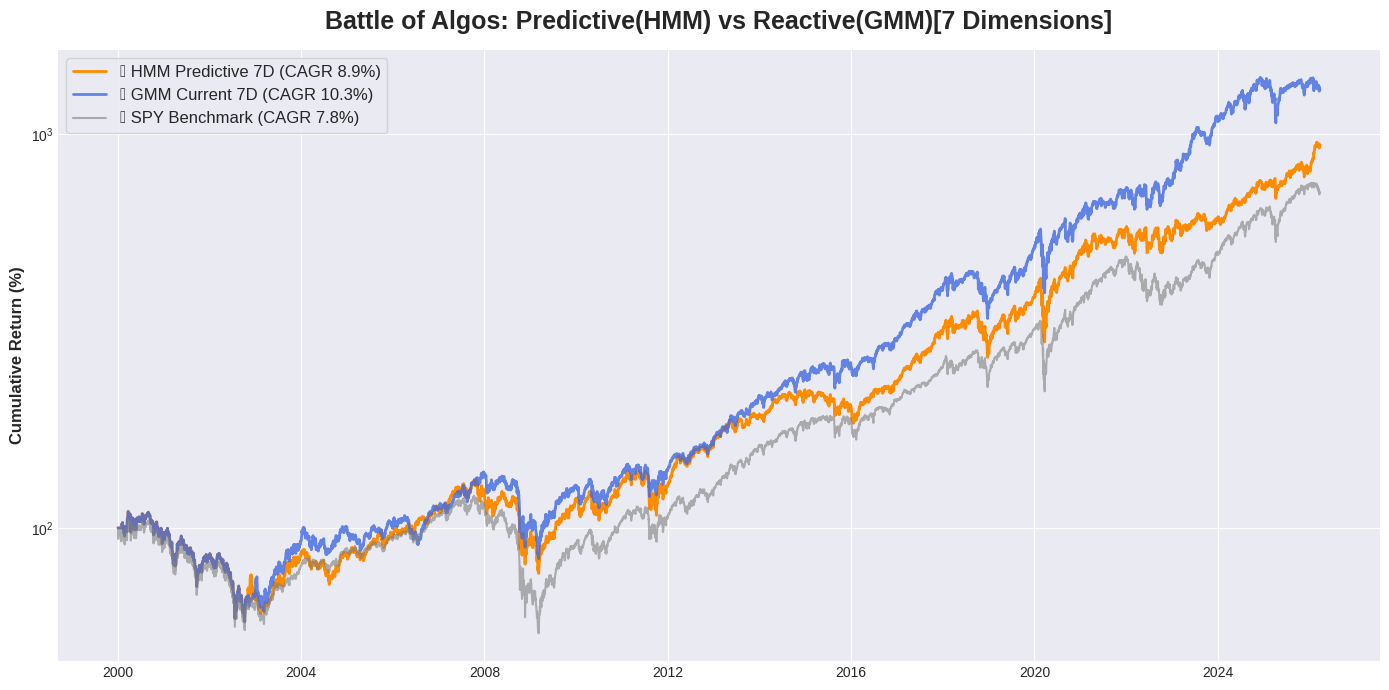

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 & 시장 데이터 로드 및 전처리 (7차원)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 & 시장 데이터 로드 및 전처리 ===")
try:
    # 1) FRED 거시경제 데이터 로드
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns =['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']

    # 💡 [수정됨] FRED 매크로 데이터가 유효하게 시작하는 최초의 날짜를 자동으로 추출!
    macro_start_date = df_macro.dropna().index.min().strftime('%Y-%m-%d')
    print(f"📊 FRED 매크로 데이터 시작일: {macro_start_date} (이 날짜에 맞춰 시장 데이터 로드)")

    # 2) 해당 날짜에 맞춰서 야후 파이낸스(S&P500, VIX) 데이터 동기화 다운로드
    market_data = yf.download(['^GSPC', '^VIX'], start=macro_start_date, progress=False)

    if 'Adj Close' in market_data.columns.get_level_values(0):
        market_px = market_data['Adj Close']
    else:
        market_px = market_data['Close']

    s_sp500 = market_px['^GSPC']
    s_vix = market_px['^VIX']

    # 매크로 데이터(월간)와 주기를 맞추기 위해 월말 데이터로 변환 후 병합
    df_macro['SP500'] = s_sp500.resample('ME').last()
    df_macro['VIX'] = s_vix.resample('ME').last()

    # 결측치 채우기 및 정리 (여기서 VIX의 시작점인 1990년 이전은 자동으로 잘려나감)
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 3) 모멘텀 계산 (7차원)
    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(12)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(12)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # 시장 데이터 피처 추가 (S&P500 추세 + VIX 이평선)
    df_macro['SP500_Mom'] = df_macro['SP500'].pct_change(3)
    df_macro['VIX_Smooth'] = df_macro['VIX'].rolling(3).mean()

    # 4) Z-Score 정규화 (롤링 60개월 기준)
    features =['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom', 'SP500_Mom', 'VIX_Smooth']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 데이터 로드 오류: {e}")
    raise ValueError("데이터 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (실전 백테스트 2000년부터)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers =['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ GMM vs HMM 타겟 비중 동시 산출
# ==============================================================================
print("=== ⚙️ 3단계: GMM(현재) vs HMM(미래) 포트폴리오 생성 ===")

eom_dates = etf_px.resample('ME').last().index

target_weights_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
target_weights_hmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx =[growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]

    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

def allocate_weights(probs_dict, date, target_df):
    threshold = 0.10
    filtered_probs = {regime: prob for regime, prob in probs_dict.items() if prob >= threshold}
    if not filtered_probs:
        dominant_regime = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant_regime: 1.0}
    total_prob = sum(filtered_probs.values())
    normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}
    for regime, prob in normalized_probs.items():
        sectors = cycle_playbook[regime]
        weight_per_sector = prob / len(sectors)
        for s in sectors:
            target_df.loc[date, s] += weight_per_sector

# 학습 루프 시작
for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    # 모델 붕괴 방지: 최소 80개월의 데이터가 쌓인 시점부터 예측 시작
    if len(df_train_current) > 80:
        current_data = df_train_current.iloc[-1:].values

        # [전략 A] GMM (과적합 방지: covariance_type='diag')
        gmm = GaussianMixture(n_components=4, covariance_type='diag', random_state=42)
        gmm.fit(df_train_current)
        regime_map_gmm = get_regime_mapping(gmm.means_)
        raw_probs_gmm = gmm.predict_proba(current_data)[0]
        current_probs_gmm = {regime_map_gmm[j]: raw_probs_gmm[j] for j in range(4)}

        allocate_weights(current_probs_gmm, date, target_weights_gmm)

        # [전략 B] HMM 예측
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            regime_map_hmm = get_regime_mapping(hmm.means_)
            hidden_states_proba = hmm.predict_proba(df_train_current)
            current_proba_hmm_raw = hidden_states_proba[-1]

            # 미래 확률 산출
            next_proba_hmm_raw = np.dot(current_proba_hmm_raw, hmm.transmat_)
            next_probs_hmm = {regime_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}

            allocate_weights(next_probs_hmm, date, target_weights_hmm)
        except:
            allocate_weights(current_probs_gmm, date, target_weights_hmm)

    else:
        target_weights_gmm.loc[date, 'SPY'] = 1.0
        target_weights_hmm.loc[date, 'SPY'] = 1.0

# ==============================================================================
# 3-2. ⚙️ 백테스트 시뮬레이터 함수 (수수료 적용)
# ==============================================================================
print("=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료 적용 ===")

target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

def run_simulation(target_weights_df, name=""):
    tw = target_weights_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    costs = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002 # 리밸런싱 비용 0.2%

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            costs[i] = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - costs[i]

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_gmm = run_simulation(target_weights_gmm, "GMM")
ret_hmm = run_simulation(target_weights_hmm, "HMM")

# ==============================================================================
# 4. 🚀 최종 성과 비교 및 시각화
# ==============================================================================
print("=== 📊 4단계: 성과 시각화 (7차원 적용) ===")

valid_start = '2000-01-01'
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
ret_gmm_valid = ret_gmm.loc[valid_start:]
ret_hmm_valid = ret_hmm.loc[valid_start:]

cum_spy = (1 + spy_ret_valid).cumprod()
cum_gmm = (1 + ret_gmm_valid).cumprod()
cum_hmm = (1 + ret_hmm_valid).cumprod()

def get_metrics(cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    return cagr, mdd

spy_c, spy_m = get_metrics(cum_spy)
gmm_c, gmm_m = get_metrics(cum_gmm)
hmm_c, hmm_m = get_metrics(cum_hmm)

print("\n" + "="*65)
print(f"🏆 7차원 (Macro + Market) 최종 백테스트 🏆")
print("="*65)
print(f"{'전략 이름':<22} | {'CAGR (%)':<12} | {'MDD (%)':<12}")
print("-" * 65)
print(f"{'🤖 1. GMM (현재 국면)':<20} | {gmm_c*100:>8.2f} % | {gmm_m*100:>8.2f} %")
print(f"{'🔮 2. HMM (미래 예측)':<20} | {hmm_c*100:>8.2f} % | {hmm_m*100:>8.2f} %")
print(f"{'📈 3. SPY (벤치마크)':<20} | {spy_c*100:>8.2f} % | {spy_m*100:>8.2f} %")
print("="*65 + "\n")

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(cum_hmm.index, cum_hmm * 100, label=f'🔮 HMM Predictive 7D (CAGR {hmm_c*100:.1f}%)', color='darkorange', linewidth=2)
plt.plot(cum_gmm.index, cum_gmm * 100, label=f'🤖 GMM Current 7D (CAGR {gmm_c*100:.1f}%)', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(cum_spy.index, cum_spy * 100, label=f'📈 SPY Benchmark (CAGR {spy_c*100:.1f}%)', color='gray', alpha=0.6)

plt.title('Battle of Algos: Predictive(HMM) vs Reactive(GMM)[7 Dimensions]', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 & 시장 데이터 로드 및 전처리 ===
📊 FRED 매크로 데이터 시작일: 1976-06-30 (이 날짜에 맞춰 시장 데이터 로드)
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: GMM(현재) vs HMM(70/30 앙상블) 1등 국면 몰빵 타겟 산출 ===


=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료/비상브레이크 적용 ===
=== 📊 4단계: GMM(현재) vs HMM(70/30 예측 블렌딩) 성과 승부 ===

🏆 GMM vs HMM (70/30 앙상블 & 1등 국면 몰빵) 백테스트 🏆
전략 이름                     | CAGR (%)   | MDD (%)   
-----------------------------------------------------------------
🤖 1. GMM (현재 국면 몰빵)  |    12.20 % |   -22.58 %
🔮 2. HMM (70/30 블렌딩 몰빵) |    10.86 % |   -18.89 %
📈 3. SPY (벤치마크)         |    11.06 % |   -55.19 %



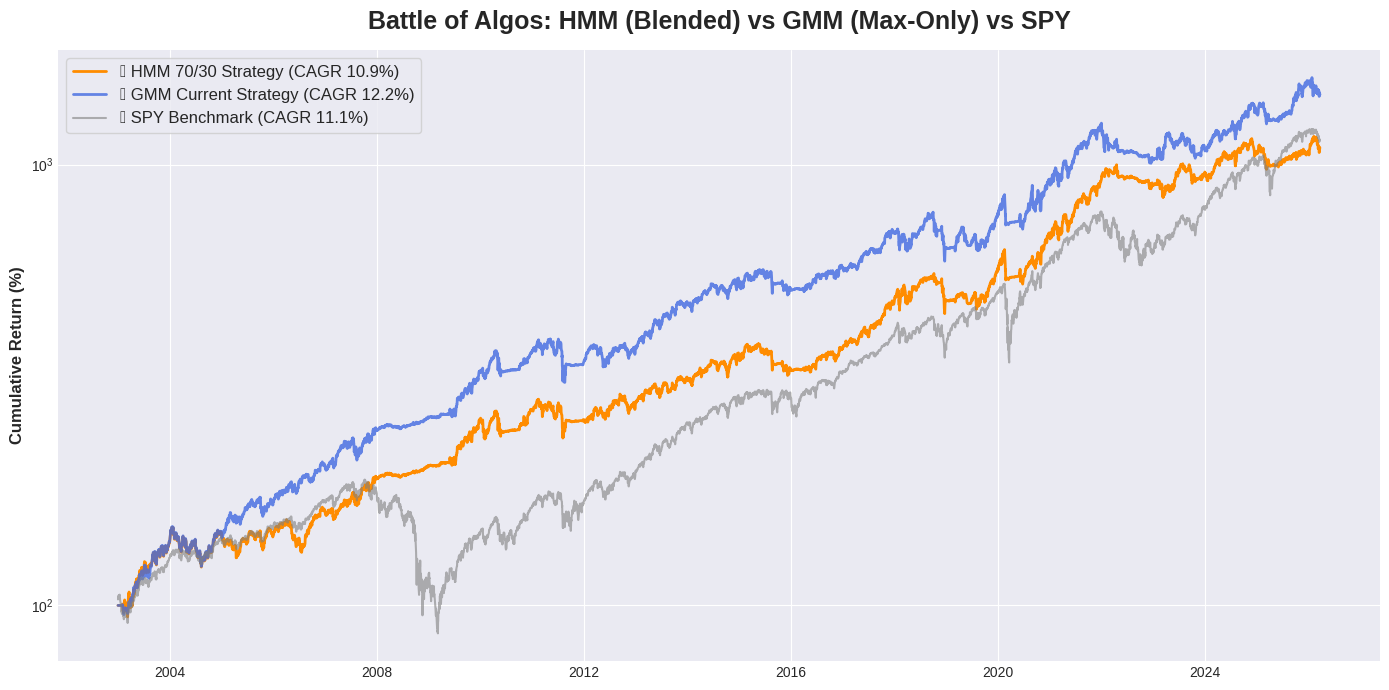

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 & 시장 데이터 로드 및 전처리 (1976년 시작으로 한계 돌파!)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 & 시장 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')

    # 💡 [핵심 수정 1] BAA10Y 한계 극복: 원본 데이터를 가져와 직접 뺍니다!
    s_baa_yield = fred.get_series('BAA')   # Baa 회사채 (1919년~)
    s_10y_yield = fred.get_series('GS10')  # 10년물 국채 (1953년~)
    s_baa = s_baa_yield - s_10y_yield      # 우리가 직접 만든 신용 스프레드

    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')   # 장단기 금리차 (1976년 6월~)

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns =['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']

    # 💡 [핵심 수정 2] 날짜 엇갈림 방지: 결측치 제거 전에 '월말' 기준으로 먼저 맞춤
    df_macro = df_macro.resample('ME').last().ffill()

    # 이제 매크로 데이터의 진정한 시작일은 T10Y2Y가 시작되는 '1976-06-30'이 됩니다.
    macro_start_date = df_macro.dropna().index.min().strftime('%Y-%m-%d')
    print(f"📊 FRED 매크로 데이터 시작일: {macro_start_date} (이 날짜에 맞춰 시장 데이터 로드)")

    # 2) 해당 날짜에 맞춰서 야후 파이낸스(S&P500, VIX) 데이터 동기화 다운로드
    market_data = yf.download(['^GSPC', '^VIX'], start=macro_start_date, progress=False)

    if 'Adj Close' in market_data.columns.get_level_values(0):
        market_px = market_data['Adj Close']
    else:
        market_px = market_data['Close']

    s_sp500 = market_px['^GSPC']
    s_vix = market_px['^VIX']

    df_macro['SP500'] = s_sp500.resample('ME').last()
    df_macro['VIX'] = s_vix.resample('ME').last()

    # 결측치 최종 정리
    df_macro = df_macro.dropna()

    # 3) 모멘텀 계산 (7차원)
    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(12)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(12)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    df_macro['SP500_Mom'] = df_macro['SP500'].pct_change(3)
    df_macro['VIX_Smooth'] = df_macro['VIX'].rolling(3).mean()

    # 4) Z-Score 정규화 (롤링 60개월 기준)
    features =['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom', 'SP500_Mom', 'VIX_Smooth']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 데이터 로드 오류: {e}")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
# 💡 SHY 대신 1991년부터 존재했던 VFISX(단기 국채 펀드) 사용
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 장기 테스트 시작일 조정
test_start_date = '2003-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 피델리티 오리지널 로직
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ GMM(현재 대응) vs HMM(70/30 블렌딩) 타겟 비중 동시 산출
# ==============================================================================
print("=== ⚙️ 3단계: GMM(현재) vs HMM(70/30 앙상블) 1등 국면 몰빵 타겟 산출 ===")

eom_dates = etf_px.resample('ME').last().index

target_weights_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
target_weights_hmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

# 피델리티 국면 라벨링 함수
def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]

    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

# 💡 [핵심 변경] 가장 확률 높은 1등 국면에만 100% 몰빵하는 함수
def allocate_weights_max_only(probs_dict, date, target_df):
    dominant_regime = max(probs_dict, key=probs_dict.get)
    sectors = cycle_playbook[dominant_regime]
    weight_per_sector = 1.0 / len(sectors)

    for s in sectors:
        target_df.loc[date, s] += weight_per_sector

# 학습 루프 시작
for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # 🤖 [전략 A] GMM: "현재 확인된 1등 국면에 투자"
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        regime_map_gmm = get_regime_mapping(gmm.means_)
        raw_probs_gmm = gmm.predict_proba(current_data)[0]
        current_probs_gmm = {regime_map_gmm[j]: raw_probs_gmm[j] for j in range(4)}

        allocate_weights_max_only(current_probs_gmm, date, target_weights_gmm)

        # 🔮 [전략 B] HMM: "현재 70% + 미래 30% 블렌딩 후 1등 국면에 투자"
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            regime_map_hmm = get_regime_mapping(hmm.means_)
            hidden_states_proba = hmm.predict_proba(df_train_current)

            current_proba_hmm_raw = hidden_states_proba[-1]
            next_proba_hmm_raw = np.dot(current_proba_hmm_raw, hmm.transmat_)

            # 💡 70/30 블렌딩 적용
            blended_proba_hmm_raw = (0.7 * current_proba_hmm_raw) + (0.3 * next_proba_hmm_raw)
            next_probs_hmm = {regime_map_hmm[j]: blended_proba_hmm_raw[j] for j in range(4)}

            allocate_weights_max_only(next_probs_hmm, date, target_weights_hmm)
        except:
            allocate_weights_max_only(current_probs_gmm, date, target_weights_hmm)

    else:
        target_weights_gmm.loc[date, 'SPY'] = 1.0
        target_weights_hmm.loc[date, 'SPY'] = 1.0

# ==============================================================================
# 3-2. ⚙️ 공정한 백테스트 시뮬레이터 함수 (200일선 비상브레이크 포함)
# ==============================================================================
print("=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료/비상브레이크 적용 ===")

target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma

def run_simulation(target_weights_df, name=""):
    tw = target_weights_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    # 💡 [버그 수정] VFISX로 완벽하게 대피하도록 적용
    bear_market_eom = is_bear_market.reindex(tw.index).fillna(False)
    for d in tw.index:
        if bear_market_eom.loc[d]:
            tw.loc[d] = 0.0
            if 'VFISX' in tw.columns: tw.loc[d, 'VFISX'] = 1.0

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    costs = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            costs[i] = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - costs[i]

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_gmm = run_simulation(target_weights_gmm, "GMM")
ret_hmm = run_simulation(target_weights_hmm, "HMM")

# ==============================================================================
# 4. 🚀 최종 성과 비교 및 시각화 (GMM vs HMM 예측 vs SPY)
# ==============================================================================
print("=== 📊 4단계: GMM(현재) vs HMM(70/30 예측 블렌딩) 성과 승부 ===")

valid_start = '2000-01-01'
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
ret_gmm_valid = ret_gmm.loc[valid_start:]
ret_hmm_valid = ret_hmm.loc[valid_start:]

cum_spy = (1 + spy_ret_valid).cumprod()
cum_gmm = (1 + ret_gmm_valid).cumprod()
cum_hmm = (1 + ret_hmm_valid).cumprod()

def get_metrics(cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    return cagr, mdd

spy_c, spy_m = get_metrics(cum_spy)
gmm_c, gmm_m = get_metrics(cum_gmm)
hmm_c, hmm_m = get_metrics(cum_hmm)

print("\n" + "="*65)
print(f"🏆 GMM vs HMM (70/30 앙상블 & 1등 국면 몰빵) 백테스트 🏆")
print("="*65)
print(f"{'전략 이름':<25} | {'CAGR (%)':<10} | {'MDD (%)':<10}")
print("-" * 65)
print(f"{'🤖 1. GMM (현재 국면 몰빵)':<20} | {gmm_c*100:>8.2f} % | {gmm_m*100:>8.2f} %")
print(f"{'🔮 2. HMM (70/30 블렌딩 몰빵)':<18} | {hmm_c*100:>8.2f} % | {hmm_m*100:>8.2f} %")
print(f"{'📈 3. SPY (벤치마크)':<23} | {spy_c*100:>8.2f} % | {spy_m*100:>8.2f} %")
print("="*65 + "\n")

# 시각화
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(cum_hmm.index, cum_hmm * 100, label=f'🔮 HMM 70/30 Strategy (CAGR {hmm_c*100:.1f}%)', color='darkorange', linewidth=2)
plt.plot(cum_gmm.index, cum_gmm * 100, label=f'🤖 GMM Current Strategy (CAGR {gmm_c*100:.1f}%)', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(cum_spy.index, cum_spy * 100, label=f'📈 SPY Benchmark (CAGR {spy_c*100:.1f}%)', color='gray', alpha=0.6)

plt.title('Battle of Algos: HMM (Blended) vs GMM (Max-Only) vs SPY', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
plt.yscale('log') # 장기 복리 효과를 명확히 보기 위해 Y축 로그 스케일 적용 필요시 주석 해제
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: 코어-위성 앙상블 타겟 산출 (GMM vs HMM) ===
=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료/비상브레이크 적용 ===
=== 📊 4단계: GMM(분산) vs HMM(코어-위성 70/30) 성과 승부 ===

🏆 GMM (분산) vs HMM (70% 분산 + 30% 미래 1등 몰빵) 🏆
전략 이름                      | CAGR (%)   | MDD (%)   
-----------------------------------------------------------------
🤖 1. GMM (100% 현재 분산) |    10.15 % |   -27.28 %
🔮 2. HMM (70/30 코어-위성) |     7.50 % |   -45.57 %
📈 3. SPY (벤치마크)         |     7.77 % |   -55.19 %



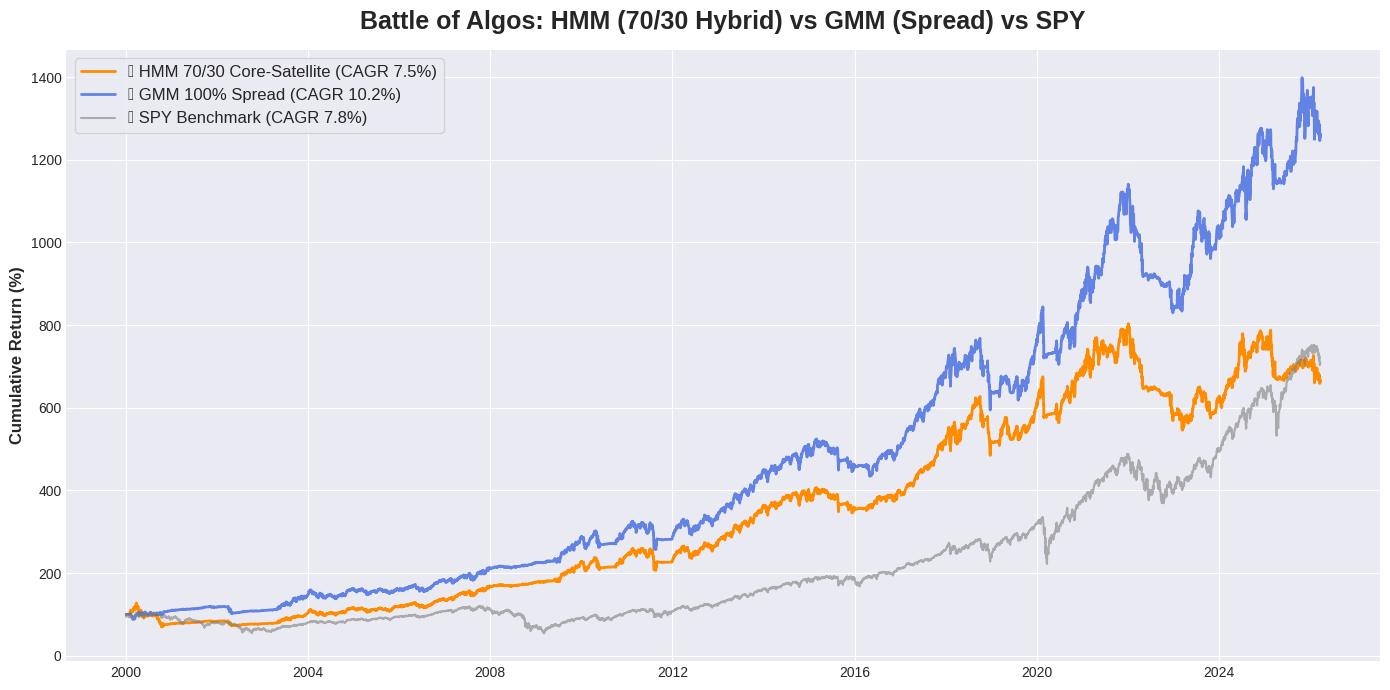

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
# 💡 SHY 대신 1991년부터 존재했던 VFISX(단기 국채 펀드) 사용
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 피델리티 오리지널 로직
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ GMM(100% 분산) vs HMM(70% 분산 + 30% 몰빵) 타겟 비중 산출
# ==============================================================================
print("=== ⚙️ 3단계: 코어-위성 앙상블 타겟 산출 (GMM vs HMM) ===")

eom_dates = etf_px.resample('ME').last().index

target_weights_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
target_weights_hmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

# 피델리티 국면 라벨링 함수
def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]

    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

# 💡 [핵심] scale 파라미터를 추가하여 원하는 비중만큼만 포트에 담도록 수정
def allocate_weights_noise_cut(probs_dict, date, target_df, scale=1.0):
    """10% 노이즈 컷 적용 후 'scale' 비중만큼 분산 투자"""
    threshold = 0.10
    filtered_probs = {regime: prob for regime, prob in probs_dict.items() if prob >= threshold}
    if not filtered_probs:
        dominant_regime = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant_regime: 1.0}
    total_prob = sum(filtered_probs.values())
    normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

    for regime, prob in normalized_probs.items():
        sectors = cycle_playbook[regime]
        weight_per_sector = (prob * scale) / len(sectors)
        for s in sectors:
            target_df.loc[date, s] += weight_per_sector

def allocate_weights_max_only(probs_dict, date, target_df, scale=1.0):
    """가장 확률 높은 1등 국면에 'scale' 비중만큼 몰빵 투자"""
    dominant_regime = max(probs_dict, key=probs_dict.get)
    sectors = cycle_playbook[dominant_regime]
    weight_per_sector = scale / len(sectors)

    for s in sectors:
        target_df.loc[date, s] += weight_per_sector

# 학습 루프 시작
for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # 🤖 [전략 A] GMM: "현재 국면에 10% 컷 100% 분산 투자"
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        regime_map_gmm = get_regime_mapping(gmm.means_)
        raw_probs_gmm = gmm.predict_proba(current_data)[0]
        current_probs_gmm = {regime_map_gmm[j]: raw_probs_gmm[j] for j in range(4)}

        # GMM은 100% (scale=1.0) 노이즈 컷 분산
        allocate_weights_noise_cut(current_probs_gmm, date, target_weights_gmm, scale=1.0)

        # 🔮 [전략 B] HMM: "현재 국면 분산(70%) + 미래 예측 1등 몰빵(30%)"
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            regime_map_hmm = get_regime_mapping(hmm.means_)
            hidden_states_proba = hmm.predict_proba(df_train_current)

            # 1. 현재 확률 산출 (70% 코어 포트폴리오 -> 노이즈 컷 분산)
            current_proba_hmm_raw = hidden_states_proba[-1]
            current_probs_hmm = {regime_map_hmm[j]: current_proba_hmm_raw[j] for j in range(4)}
            allocate_weights_noise_cut(current_probs_hmm, date, target_weights_hmm, scale=0.7)

            # 2. 미래(다음 달) 확률 산출 (30% 위성 포트폴리오 -> 1등 몰빵)
            next_proba_hmm_raw = np.dot(current_proba_hmm_raw, hmm.transmat_)
            next_probs_hmm = {regime_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}
            allocate_weights_max_only(next_probs_hmm, date, target_weights_hmm, scale=0.3)

        except:
            # HMM 학습 실패 시 GMM 결과로 100% 분산 대체 (안전장치)
            allocate_weights_noise_cut(current_probs_gmm, date, target_weights_hmm, scale=1.0)

    else:
        target_weights_gmm.loc[date, 'SPY'] = 1.0
        target_weights_hmm.loc[date, 'SPY'] = 1.0

# ==============================================================================
# 3-2. ⚙️ 공정한 백테스트 시뮬레이터 함수 (200일선 비상브레이크 포함)
# ==============================================================================
print("=== ⚙️ 3-2단계: 각 전략별 실전 매매 및 수수료/비상브레이크 적용 ===")

target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma

def run_simulation(target_weights_df, name=""):
    tw = target_weights_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    # VFISX로 완벽하게 대피하도록 적용
    bear_market_eom = is_bear_market.reindex(tw.index).fillna(False)
    for d in tw.index:
        if bear_market_eom.loc[d]:
            tw.loc[d] = 0.0
            if 'VFISX' in tw.columns: tw.loc[d, 'VFISX'] = 1.0

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    costs = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            costs[i] = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - costs[i]

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_gmm = run_simulation(target_weights_gmm, "GMM")
ret_hmm = run_simulation(target_weights_hmm, "HMM")

# ==============================================================================
# 4. 🚀 최종 성과 비교 및 시각화 (GMM vs HMM 예측 vs SPY)
# ==============================================================================
print("=== 📊 4단계: GMM(분산) vs HMM(코어-위성 70/30) 성과 승부 ===")

valid_start = '2000-01-01'
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
ret_gmm_valid = ret_gmm.loc[valid_start:]
ret_hmm_valid = ret_hmm.loc[valid_start:]

cum_spy = (1 + spy_ret_valid).cumprod()
cum_gmm = (1 + ret_gmm_valid).cumprod()
cum_hmm = (1 + ret_hmm_valid).cumprod()

def get_metrics(cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    return cagr, mdd

spy_c, spy_m = get_metrics(cum_spy)
gmm_c, gmm_m = get_metrics(cum_gmm)
hmm_c, hmm_m = get_metrics(cum_hmm)

print("\n" + "="*65)
print(f"🏆 GMM (분산) vs HMM (70% 분산 + 30% 미래 1등 몰빵) 🏆")
print("="*65)
print(f"{'전략 이름':<26} | {'CAGR (%)':<10} | {'MDD (%)':<10}")
print("-" * 65)
print(f"{'🤖 1. GMM (100% 현재 분산)':<20} | {gmm_c*100:>8.2f} % | {gmm_m*100:>8.2f} %")
print(f"{'🔮 2. HMM (70/30 코어-위성)':<20} | {hmm_c*100:>8.2f} % | {hmm_m*100:>8.2f} %")
print(f"{'📈 3. SPY (벤치마크)':<23} | {spy_c*100:>8.2f} % | {spy_m*100:>8.2f} %")
print("="*65 + "\n")

# 시각화
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(cum_hmm.index, cum_hmm * 100, label=f'🔮 HMM 70/30 Core-Satellite (CAGR {hmm_c*100:.1f}%)', color='darkorange', linewidth=2)
plt.plot(cum_gmm.index, cum_gmm * 100, label=f'🤖 GMM 100% Spread (CAGR {gmm_c*100:.1f}%)', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(cum_spy.index, cum_spy * 100, label=f'📈 SPY Benchmark (CAGR {spy_c*100:.1f}%)', color='gray', alpha=0.6)

plt.title('Battle of Algos: HMM (70/30 Hybrid) vs GMM (Spread) vs SPY', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
#plt.yscale('log') # 필요시 주석 해제
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: GMM-HMM 앙상블 타겟 산출 ===
=== ⚙️ 3-2단계: 실전 매매 및 수수료/비상브레이크 적용 ===
=== 📊 4단계: GMM 단독 vs GMM-HMM 하이브리드 성과 승부 ===

🏆 GMM 단독 vs GMM-HMM 하이브리드 (GMM 70% + HMM 30%) 🏆
전략 이름                          | CAGR (%)   | MDD (%)   
----------------------------------------------------------------------
🤖 1. GMM Only (100% 현재 분산) |    10.15 % |   -27.28 %
🧬 2. 하이브리드 (GMM 70% + HMM 30%) |     9.47 % |   -28.31 %
📈 3. SPY (벤치마크)              |     7.77 % |   -55.19 %



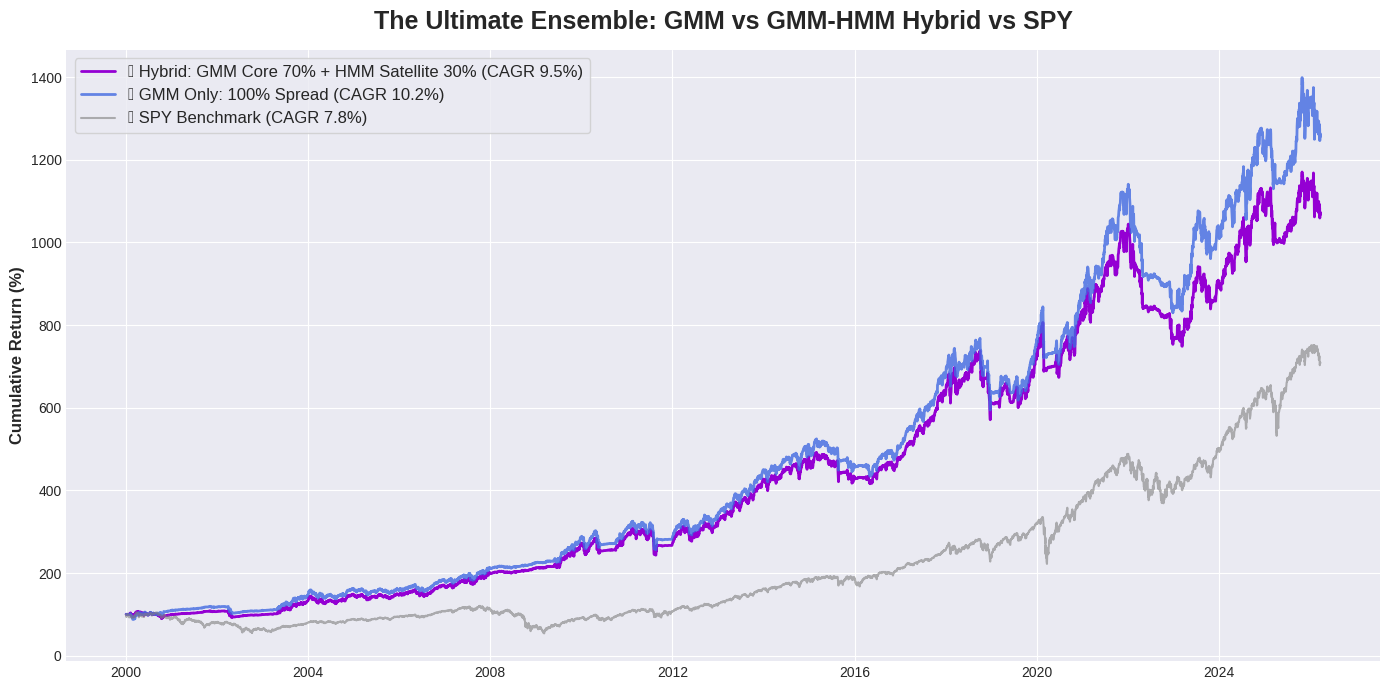

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ GMM 단독 vs GMM-HMM 하이브리드 타겟 비중 산출
# ==============================================================================
print("=== ⚙️ 3단계: GMM-HMM 앙상블 타겟 산출 ===")

eom_dates = etf_px.resample('ME').last().index

target_weights_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
target_weights_hybrid = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]

    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

def allocate_weights_noise_cut(probs_dict, date, target_df, scale=1.0):
    threshold = 0.10
    filtered_probs = {regime: prob for regime, prob in probs_dict.items() if prob >= threshold}
    if not filtered_probs:
        dominant_regime = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant_regime: 1.0}
    total_prob = sum(filtered_probs.values())
    normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

    for regime, prob in normalized_probs.items():
        sectors = cycle_playbook[regime]
        weight_per_sector = (prob * scale) / len(sectors)
        for s in sectors:
            target_df.loc[date, s] += weight_per_sector

def allocate_weights_max_only(probs_dict, date, target_df, scale=1.0):
    dominant_regime = max(probs_dict, key=probs_dict.get)
    sectors = cycle_playbook[dominant_regime]
    weight_per_sector = scale / len(sectors)

    for s in sectors:
        target_df.loc[date, s] += weight_per_sector

# 학습 루프 시작
for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # 🤖 [기본 전략] GMM: 현재 국면 100% 분산 투자
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        regime_map_gmm = get_regime_mapping(gmm.means_)
        raw_probs_gmm = gmm.predict_proba(current_data)[0]
        current_probs_gmm = {regime_map_gmm[j]: raw_probs_gmm[j] for j in range(4)}

        allocate_weights_noise_cut(current_probs_gmm, date, target_weights_gmm, scale=1.0)

        # 🧬 [하이브리드 전략] GMM 현재 분산(70%) + HMM 미래 몰빵(30%)
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            regime_map_hmm = get_regime_mapping(hmm.means_)
            hidden_states_proba = hmm.predict_proba(df_train_current)

            # HMM 미래 확률 산출 (위성 포트폴리오용)
            current_proba_hmm_raw = hidden_states_proba[-1]
            next_proba_hmm_raw = np.dot(current_proba_hmm_raw, hmm.transmat_)
            next_probs_hmm = {regime_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}

            # 💡 [핵심] GMM의 확률로 70% 분산 + HMM의 미래 확률로 30% 몰빵!
            allocate_weights_noise_cut(current_probs_gmm, date, target_weights_hybrid, scale=0.7)
            allocate_weights_max_only(next_probs_hmm, date, target_weights_hybrid, scale=0.3)

        except:
            # HMM 학습 실패 시, 안전하게 GMM 100%로 대체
            allocate_weights_noise_cut(current_probs_gmm, date, target_weights_hybrid, scale=1.0)

    else:
        target_weights_gmm.loc[date, 'SPY'] = 1.0
        target_weights_hybrid.loc[date, 'SPY'] = 1.0

# ==============================================================================
# 3-2. ⚙️ 공정한 백테스트 시뮬레이터 함수
# ==============================================================================
print("=== ⚙️ 3-2단계: 실전 매매 및 수수료/비상브레이크 적용 ===")

target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma

def run_simulation(target_weights_df, name=""):
    tw = target_weights_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    bear_market_eom = is_bear_market.reindex(tw.index).fillna(False)
    for d in tw.index:
        if bear_market_eom.loc[d]:
            tw.loc[d] = 0.0
            if 'VFISX' in tw.columns: tw.loc[d, 'VFISX'] = 1.0

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    costs = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            costs[i] = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - costs[i]

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_gmm = run_simulation(target_weights_gmm, "GMM")
ret_hybrid = run_simulation(target_weights_hybrid, "Hybrid")

# ==============================================================================
# 4. 🚀 최종 성과 비교 및 시각화
# ==============================================================================
print("=== 📊 4단계: GMM 단독 vs GMM-HMM 하이브리드 성과 승부 ===")

valid_start = '2000-01-01'
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
ret_gmm_valid = ret_gmm.loc[valid_start:]
ret_hybrid_valid = ret_hybrid.loc[valid_start:]

cum_spy = (1 + spy_ret_valid).cumprod()
cum_gmm = (1 + ret_gmm_valid).cumprod()
cum_hybrid = (1 + ret_hybrid_valid).cumprod()

def get_metrics(cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    return cagr, mdd

spy_c, spy_m = get_metrics(cum_spy)
gmm_c, gmm_m = get_metrics(cum_gmm)
hybrid_c, hybrid_m = get_metrics(cum_hybrid)

print("\n" + "="*70)
print(f"🏆 GMM 단독 vs GMM-HMM 하이브리드 (GMM 70% + HMM 30%) 🏆")
print("="*70)
print(f"{'전략 이름':<30} | {'CAGR (%)':<10} | {'MDD (%)':<10}")
print("-" * 70)
print(f"{'🤖 1. GMM Only (100% 현재 분산)':<26} | {gmm_c*100:>8.2f} % | {gmm_m*100:>8.2f} %")
print(f"{'🧬 2. 하이브리드 (GMM 70% + HMM 30%)':<22} | {hybrid_c*100:>8.2f} % | {hybrid_m*100:>8.2f} %")
print(f"{'📈 3. SPY (벤치마크)':<28} | {spy_c*100:>8.2f} % | {spy_m*100:>8.2f} %")
print("="*70 + "\n")

# 시각화
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(cum_hybrid.index, cum_hybrid * 100, label=f'🧬 Hybrid: GMM Core 70% + HMM Satellite 30% (CAGR {hybrid_c*100:.1f}%)', color='darkviolet', linewidth=2)
plt.plot(cum_gmm.index, cum_gmm * 100, label=f'🤖 GMM Only: 100% Spread (CAGR {gmm_c*100:.1f}%)', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(cum_spy.index, cum_spy * 100, label=f'📈 SPY Benchmark (CAGR {spy_c*100:.1f}%)', color='gray', alpha=0.6)

plt.title('The Ultimate Ensemble: GMM vs GMM-HMM Hybrid vs SPY', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
#plt.yscale('log') # 필요시 주석 해제
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: GMM 단독 vs 확신도 기반 Dynamic 하이브리드 산출 ===
=== ⚙️ 3-2단계: 실전 매매 및 수수료/비상브레이크 적용 ===
=== 📊 4단계: GMM 단독 vs Dynamic 확신도 하이브리드 ===

🏆 GMM 단독 vs 🧬 Dynamic 확신도 기반 하이브리드 🏆
전략 이름                          | CAGR (%)   | MDD (%)   
----------------------------------------------------------------------
🤖 1. GMM Only (100% 현재 분산) |    10.70 % |   -44.05 %
🧬 2. 하이브리드 (Dynamic 확신도) |     9.93 % |   -46.77 %
📈 3. SPY (벤치마크)              |     7.79 % |   -55.19 %



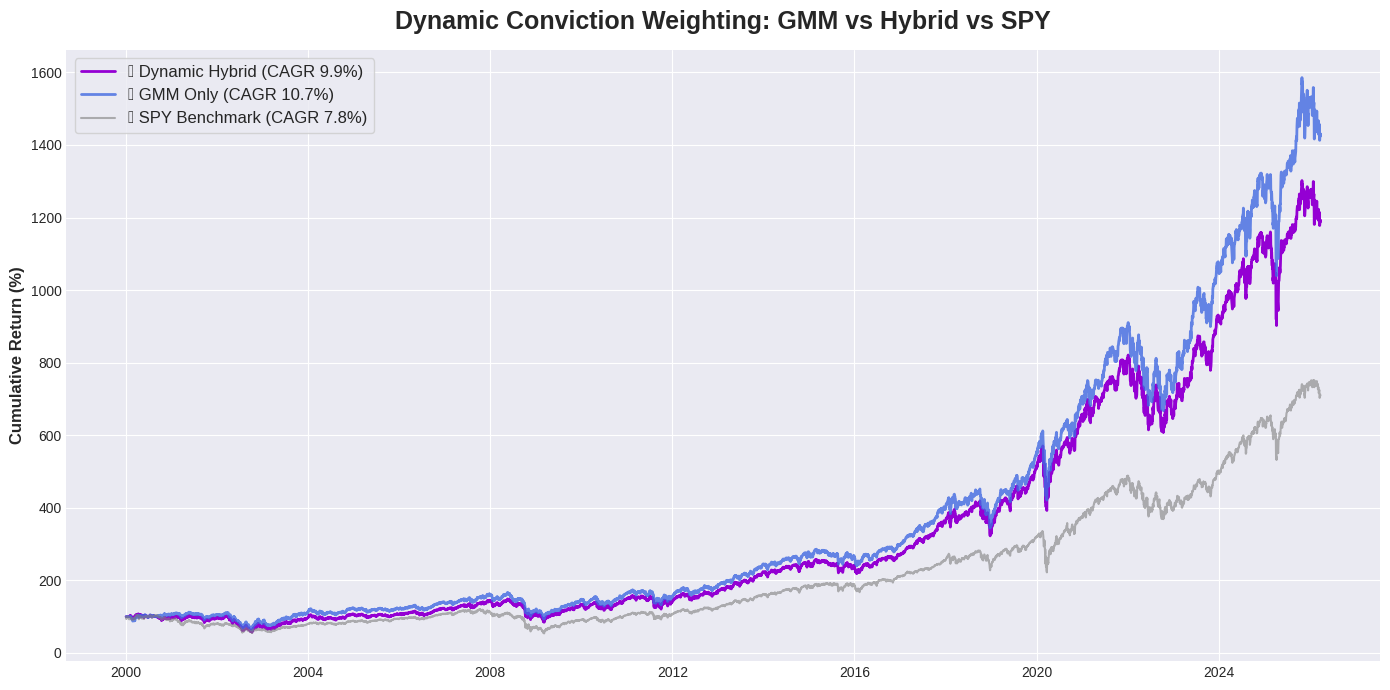

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ GMM 단독 vs Dynamic 하이브리드 타겟 비중 산출
# ==============================================================================
print("=== ⚙️ 3단계: GMM 단독 vs 확신도 기반 Dynamic 하이브리드 산출 ===")

eom_dates = etf_px.resample('ME').last().index

target_weights_gmm = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
target_weights_hybrid = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

def get_regime_mapping(centroids):
    growth_sorted_idx = np.argsort(centroids[:, 0])
    idx_recession = growth_sorted_idx[0]
    idx_early = growth_sorted_idx[-1]

    rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
    if centroids[rem_idx[0], 1] > centroids[rem_idx[1], 1]:
        idx_late, idx_mid = rem_idx[0], rem_idx[1]
    else:
        idx_late, idx_mid = rem_idx[1], rem_idx[0]

    return {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

def allocate_weights_noise_cut(probs_dict, date, target_df, scale=1.0):
    threshold = 0.10
    filtered_probs = {regime: prob for regime, prob in probs_dict.items() if prob >= threshold}
    if not filtered_probs:
        dominant_regime = max(probs_dict, key=probs_dict.get)
        filtered_probs = {dominant_regime: 1.0}
    total_prob = sum(filtered_probs.values())
    normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

    for regime, prob in normalized_probs.items():
        sectors = cycle_playbook[regime]
        weight_per_sector = (prob * scale) / len(sectors)
        for s in sectors:
            target_df.loc[date, s] += weight_per_sector

def allocate_weights_max_only(probs_dict, date, target_df, scale=1.0):
    dominant_regime = max(probs_dict, key=probs_dict.get)
    sectors = cycle_playbook[dominant_regime]
    weight_per_sector = scale / len(sectors)

    for s in sectors:
        target_df.loc[date, s] += weight_per_sector

# 학습 루프 시작
for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        current_data = df_train_current.iloc[-1:].values

        # 🤖 [기본 전략] GMM: 현재 국면 100% 분산 투자
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        regime_map_gmm = get_regime_mapping(gmm.means_)
        raw_probs_gmm = gmm.predict_proba(current_data)[0]
        current_probs_gmm = {regime_map_gmm[j]: raw_probs_gmm[j] for j in range(4)}

        allocate_weights_noise_cut(current_probs_gmm, date, target_weights_gmm, scale=1.0)

        # 🧬 [Dynamic 하이브리드] HMM 확신도에 따른 비중 조절
        hmm = GaussianHMM(n_components=4, covariance_type='diag', random_state=42, n_iter=500, tol=0.01)
        try:
            hmm.fit(df_train_current)
            regime_map_hmm = get_regime_mapping(hmm.means_)
            hidden_states_proba = hmm.predict_proba(df_train_current)

            # HMM 미래 확률 산출
            current_proba_hmm_raw = hidden_states_proba[-1]
            next_proba_hmm_raw = np.dot(current_proba_hmm_raw, hmm.transmat_)

            # 💡 [솔루션 1] 확신도(최대 확률) 측정
            max_next_prob = np.max(next_proba_hmm_raw)

            if max_next_prob >= 0.60:
                # 🎯 확신도가 60% 이상일 때만: GMM 70% + HMM 30% 배팅
                scale_gmm = 0.7
                scale_hmm = 0.3
            else:
                # 🤷‍♂️ 확신도가 낮을 때: GMM 100% (HMM은 이번 달 휴식)
                scale_gmm = 1.0
                scale_hmm = 0.0

            next_probs_hmm = {regime_map_hmm[j]: next_proba_hmm_raw[j] for j in range(4)}

            # 계산된 비중(scale)대로 할당
            allocate_weights_noise_cut(current_probs_gmm, date, target_weights_hybrid, scale=scale_gmm)
            if scale_hmm > 0:
                allocate_weights_max_only(next_probs_hmm, date, target_weights_hybrid, scale=scale_hmm)

        except:
            # 학습 실패 시 안전장치 (GMM 100%)
            allocate_weights_noise_cut(current_probs_gmm, date, target_weights_hybrid, scale=1.0)

    else:
        target_weights_gmm.loc[date, 'SPY'] = 1.0
        target_weights_hybrid.loc[date, 'SPY'] = 1.0

# ==============================================================================
# 3-2. ⚙️ 공정한 백테스트 시뮬레이터 함수
# ==============================================================================
print("=== ⚙️ 3-2단계: 실전 매매 및 수수료/비상브레이크 적용 ===")

target_months = eom_dates.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])
aligned_index = target_months.map(last_trading_days)

spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma

def run_simulation(target_weights_df, name=""):
    tw = target_weights_df.copy()
    tw.index = aligned_index
    tw = tw[tw.index.notna()]

    #bear_market_eom = is_bear_market.reindex(tw.index).fillna(False)
    #for d in tw.index:
    #    if bear_market_eom.loc[d]:
    #        tw.loc[d] = 0.0
    #        if 'VFISX' in tw.columns: tw.loc[d, 'VFISX'] = 1.0

    tw_aligned = tw.reindex(daily_returns.index)
    reb_signals = tw_aligned.shift(1)
    is_reb_day = ~reb_signals.isna().all(axis=1)

    zero_mask = is_reb_day & (reb_signals.sum(axis=1) == 0)
    reb_signals.loc[zero_mask, 'SPY'] = 1.0

    r_vals = daily_returns.values
    t_vals = reb_signals.fillna(0.0).values
    reb_day_arr = is_reb_day.values

    n_d = len(daily_returns)
    n_a = len(daily_returns.columns)

    port_ret = np.zeros(n_d)
    costs = np.zeros(n_d)
    c_weights = np.zeros(n_a)
    fee_rate = 0.002

    for i in range(n_d):
        if reb_day_arr[i]:
            target_w = t_vals[i]
            costs[i] = np.sum(np.abs(target_w - c_weights)) * fee_rate
            c_weights = target_w.copy()

        day_r = np.sum(c_weights * r_vals[i])
        port_ret[i] = day_r - costs[i]

        if (1 + day_r) > 0: c_weights = c_weights * (1 + r_vals[i]) / (1 + day_r)
        else: c_weights = np.zeros(n_a)

    return pd.Series(port_ret, index=daily_returns.index)

ret_gmm = run_simulation(target_weights_gmm, "GMM")
ret_hybrid = run_simulation(target_weights_hybrid, "Hybrid")

# ==============================================================================
# 4. 🚀 최종 성과 비교 및 시각화
# ==============================================================================
print("=== 📊 4단계: GMM 단독 vs Dynamic 확신도 하이브리드 ===")

valid_start = '2000-01-01'
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
ret_gmm_valid = ret_gmm.loc[valid_start:]
ret_hybrid_valid = ret_hybrid.loc[valid_start:]

cum_spy = (1 + spy_ret_valid).cumprod()
cum_gmm = (1 + ret_gmm_valid).cumprod()
cum_hybrid = (1 + ret_hybrid_valid).cumprod()

def get_metrics(cum):
    years = len(cum) / 252
    cagr = (cum.iloc[-1] ** (1 / years)) - 1
    mdd = (cum / cum.cummax() - 1).min()
    return cagr, mdd

spy_c, spy_m = get_metrics(cum_spy)
gmm_c, gmm_m = get_metrics(cum_gmm)
hybrid_c, hybrid_m = get_metrics(cum_hybrid)

print("\n" + "="*70)
print(f"🏆 GMM 단독 vs 🧬 Dynamic 확신도 기반 하이브리드 🏆")
print("="*70)
print(f"{'전략 이름':<30} | {'CAGR (%)':<10} | {'MDD (%)':<10}")
print("-" * 70)
print(f"{'🤖 1. GMM Only (100% 현재 분산)':<26} | {gmm_c*100:>8.2f} % | {gmm_m*100:>8.2f} %")
print(f"{'🧬 2. 하이브리드 (Dynamic 확신도)':<23} | {hybrid_c*100:>8.2f} % | {hybrid_m*100:>8.2f} %")
print(f"{'📈 3. SPY (벤치마크)':<28} | {spy_c*100:>8.2f} % | {spy_m*100:>8.2f} %")
print("="*70 + "\n")

# 시각화
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14, 7))

plt.plot(cum_hybrid.index, cum_hybrid * 100, label=f'🧬 Dynamic Hybrid (CAGR {hybrid_c*100:.1f}%)', color='darkviolet', linewidth=2)
plt.plot(cum_gmm.index, cum_gmm * 100, label=f'🤖 GMM Only (CAGR {gmm_c*100:.1f}%)', color='royalblue', linewidth=2, alpha=0.8)
plt.plot(cum_spy.index, cum_spy * 100, label=f'📈 SPY Benchmark (CAGR {spy_c*100:.1f}%)', color='gray', alpha=0.6)

plt.title('Dynamic Conviction Weighting: GMM vs Hybrid vs SPY', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()